# Notebook 02 - Khách hàng và thị trường

**Mục tiêu:** phân tích tăng trưởng khách hàng, hành vi mua lại, hiệu quả kênh acquisition, khác biệt theo nhân khẩu học và khu vực. Notebook này giúp xác định nhóm khách hàng/thị trường nên ưu tiên.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "datathon-2026-round-1").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from EDA.constants.config import FIGURES_DIR, WEEKDAY_ORDER, AGE_ORDER, SIZE_ORDER
from EDA.utils.io import load_tables, build_order_metrics, build_order_item_metrics
from EDA.utils.plotting import setup_vietnamese_style, save_figure, format_money_axis, format_percent_axis, money_formatter
from EDA.utils.validation import quality_report, foreign_key_report

setup_vietnamese_style()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Tải dữ liệu và tạo bảng fact cấp đơn hàng

In [2]:
tables = load_tables(["orders", "order_items", "customers", "geography", "payments"])
orders, items, customers, geography, payments = tables["orders"], tables["order_items"], tables["customers"], tables["geography"], tables["payments"]
display(quality_report(tables))
order_metrics = build_order_metrics(items)
cdim = customers.rename(columns={"zip": "customer_zip", "city": "customer_city"})
gdim = geography.rename(columns={"zip": "ship_zip", "city": "ship_city"})
fact = orders.merge(order_metrics, on="order_id", how="left").merge(cdim, on="customer_id", how="left").merge(gdim, left_on="zip", right_on="ship_zip", how="left").merge(payments[["order_id", "payment_value", "installments"]], on="order_id", how="left")
fact["order_month"] = fact.order_date.dt.to_period("M").dt.to_timestamp()
display(Markdown(f"**Insight ngắn:** có {customers.customer_id.nunique():,} khách trong master, {orders.customer_id.nunique():,} khách đã phát sinh đơn, tương đương {orders.customer_id.nunique()/customers.customer_id.nunique():.2%}."))

,bảng,số dòng,số cột,ô thiếu,dòng trùng,dung lượng MB
2,customers,121930,7,0,0,32.7700
3,geography,39948,4,0,0,7.7800
1,order_items,714669,7,1152816,0,80.1100
0,orders,646945,8,0,0,182.5200
4,payments,646945,4,0,0,55.5000


**Insight ngắn:** có 121,930 khách trong master, 90,246 khách đã phát sinh đơn, tương đương 74.01%.

## 2. Tăng trưởng khách hàng và hành vi mua lại

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


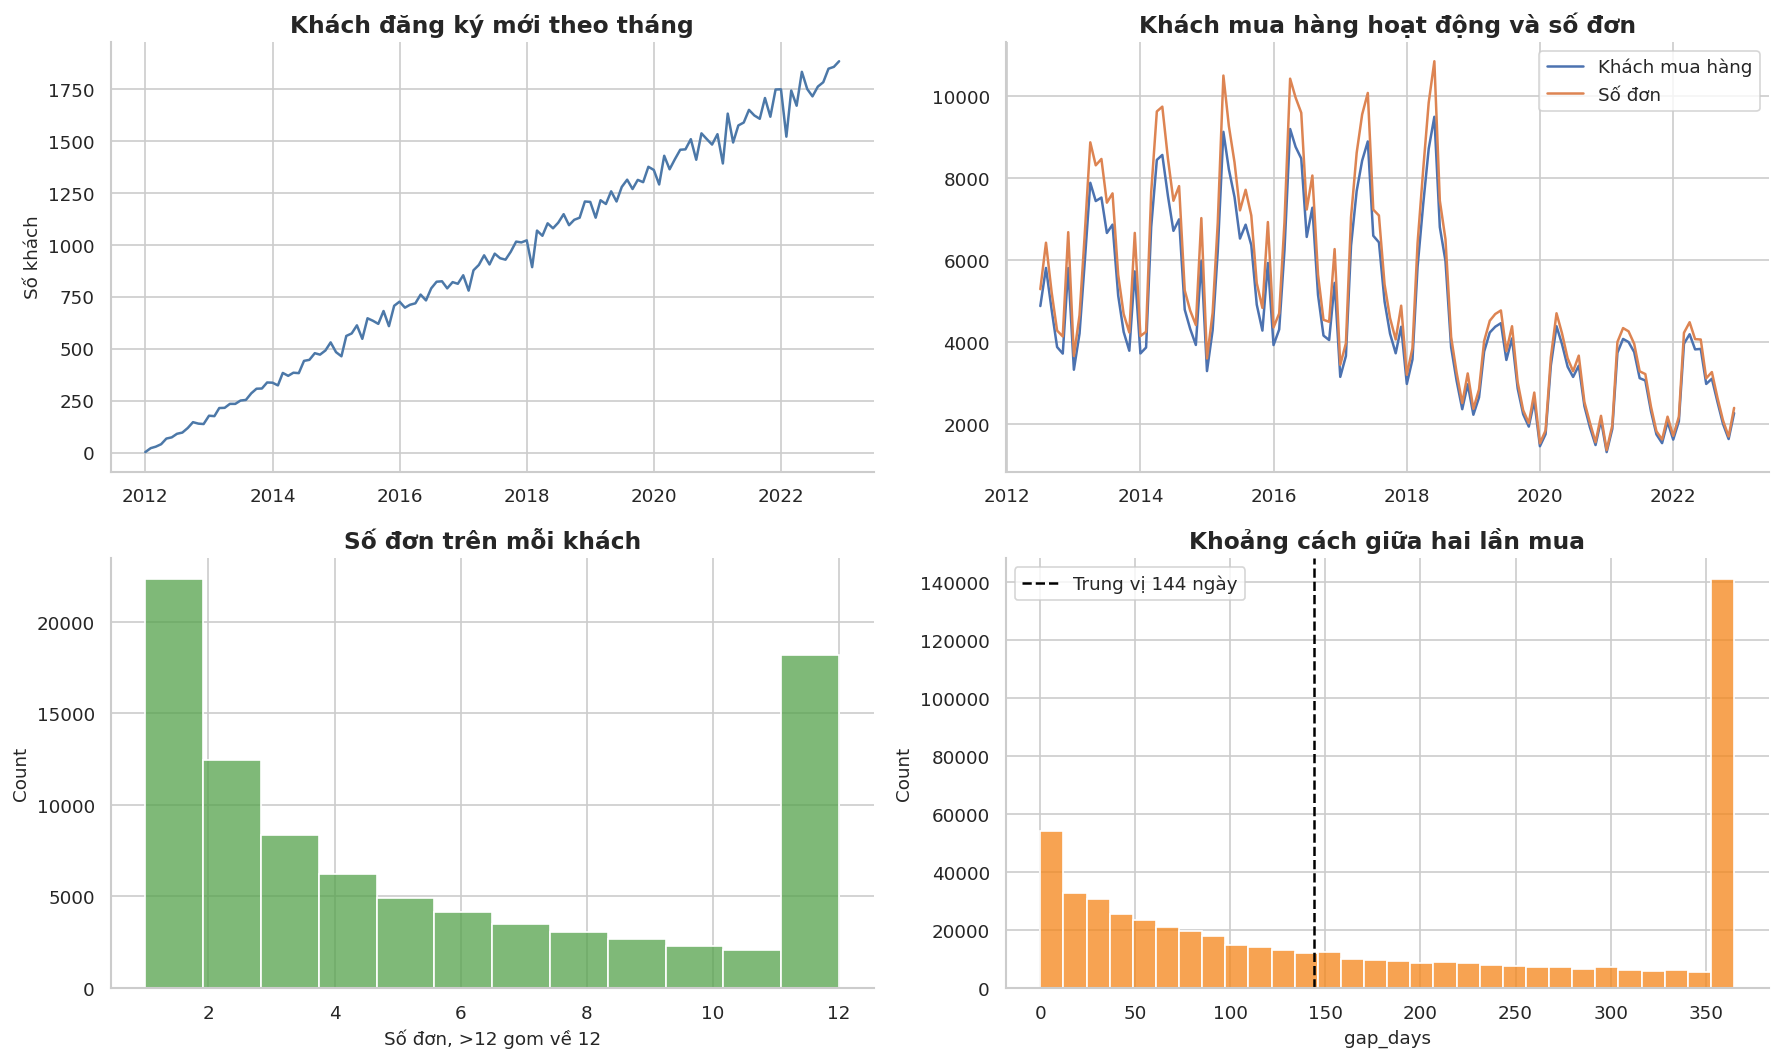

**Insight ngắn:** 75.23% khách mua hơn một lần; trung vị inter-order gap là 144 ngày. Đây là mốc hữu ích để thiết kế CRM/retention.

In [3]:
signups = customers.assign(signup_month=customers.signup_date.dt.to_period("M").dt.to_timestamp()).groupby("signup_month", as_index=False).agg(new_customers=("customer_id", "nunique"))
active = fact.groupby("order_month", as_index=False).agg(active_customers=("customer_id", "nunique"), orders=("order_id", "nunique"), net_sales=("net_sales", "sum"))
cust_orders = fact.groupby("customer_id", as_index=False).agg(order_count=("order_id", "nunique"), first_order=("order_date", "min"), last_order=("order_date", "max"), total_net_sales=("net_sales", "sum"), avg_order_value=("net_sales", "mean"))
gaps = orders.sort_values(["customer_id", "order_date"]).assign(prev=lambda d: d.groupby("customer_id").order_date.shift(1))
gaps["gap_days"] = (gaps.order_date - gaps.prev).dt.days
repeat_share = (cust_orders.order_count > 1).mean()
median_gap = gaps.gap_days.dropna().median()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes[0,0].plot(signups.signup_month, signups.new_customers, color="#4c78a8"); axes[0,0].set_title("Khách đăng ký mới theo tháng"); axes[0,0].set_ylabel("Số khách")
axes[0,1].plot(active.order_month, active.active_customers, label="Khách mua hàng"); axes[0,1].plot(active.order_month, active.orders, label="Số đơn"); axes[0,1].set_title("Khách mua hàng hoạt động và số đơn"); axes[0,1].legend()
sns.histplot(cust_orders.order_count.clip(upper=12), bins=12, color="#54a24b", ax=axes[1,0]); axes[1,0].set_title("Số đơn trên mỗi khách"); axes[1,0].set_xlabel("Số đơn, >12 gom về 12")
sns.histplot(gaps.gap_days.dropna().clip(upper=365), bins=30, color="#f58518", ax=axes[1,1]); axes[1,1].axvline(median_gap, color="black", linestyle="--", label=f"Trung vị {median_gap:.0f} ngày"); axes[1,1].set_title("Khoảng cách giữa hai lần mua"); axes[1,1].legend()
save_figure("02_customer_market_growth_repeat", fig); plt.show()
display(Markdown(f"**Insight ngắn:** {repeat_share:.2%} khách mua hơn một lần; trung vị inter-order gap là {median_gap:.0f} ngày. Đây là mốc hữu ích để thiết kế CRM/retention."))

## 3. Nhân khẩu học, acquisition và thị trường

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


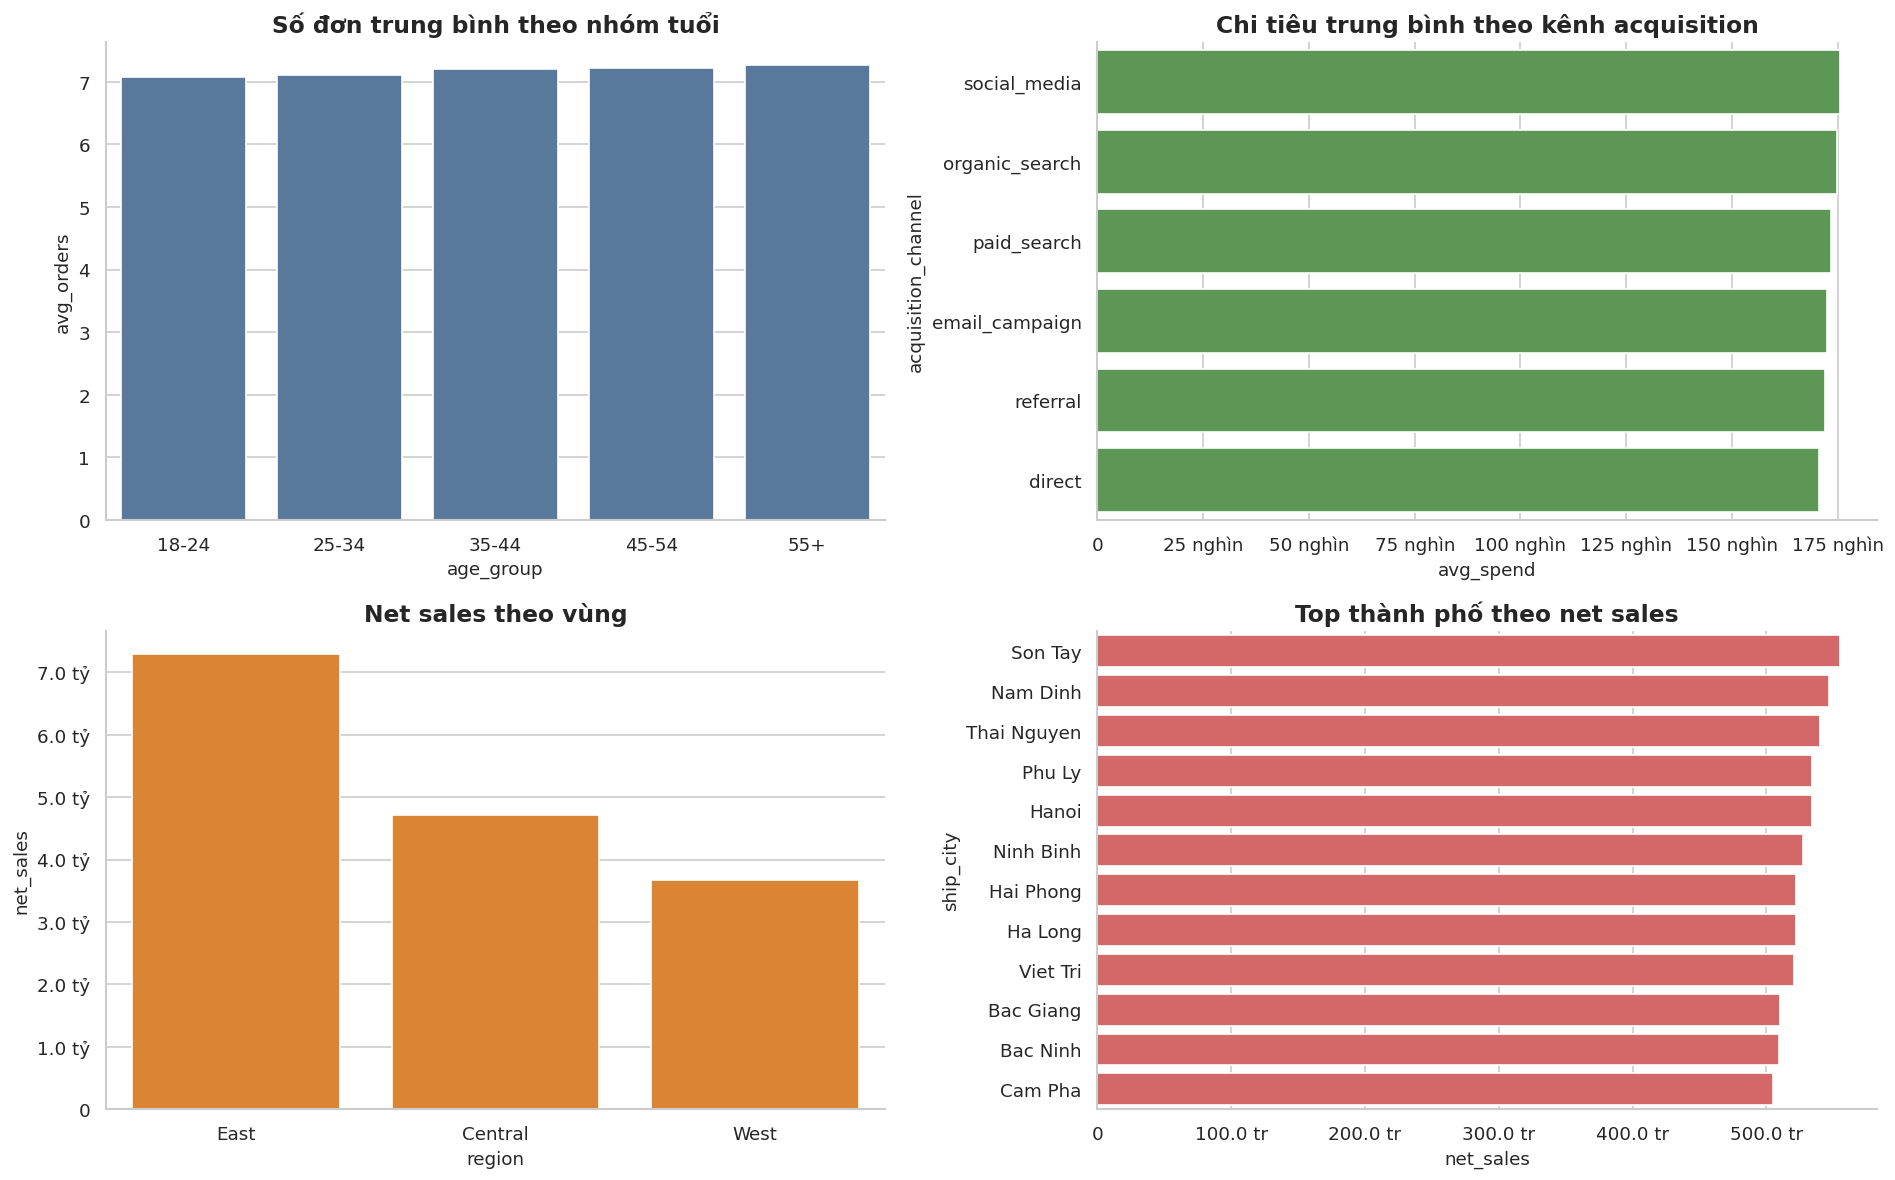

,region,orders,customers,net_sales,aov,cancel_rate
1,East,294612,44721,"7,291,150,819","24,748",9.20%
0,Central,184691,30784,"4,719,491,268","25,553",9.26%
2,West,167642,14741,"3,670,227,178","21,893",9.09%


**Insight ngắn:** nhóm tuổi `55+` có số đơn trung bình cao nhất; kênh `social_media` có chi tiêu/khách cao nhất; vùng `East` dẫn đầu net sales.

In [4]:
profile = cust_orders.merge(cdim, on="customer_id", how="left")
age = profile.groupby("age_group", as_index=False).agg(customers=("customer_id", "nunique"), avg_orders=("order_count", "mean"), avg_spend=("total_net_sales", "mean"))
age["age_group"] = pd.Categorical(age.age_group, AGE_ORDER, ordered=True); age = age.sort_values("age_group")
acq = profile.groupby("acquisition_channel", as_index=False).agg(customers=("customer_id", "nunique"), avg_orders=("order_count", "mean"), avg_spend=("total_net_sales", "mean")).sort_values("avg_spend", ascending=False)
region = fact.groupby("region", as_index=False).agg(orders=("order_id", "nunique"), customers=("customer_id", "nunique"), net_sales=("net_sales", "sum"), aov=("net_sales", "mean"), cancel_rate=("order_status", lambda x: (x == "cancelled").mean())).sort_values("net_sales", ascending=False)
city = fact.groupby("ship_city", as_index=False).agg(net_sales=("net_sales", "sum"), orders=("order_id", "nunique")).sort_values("net_sales", ascending=False).head(12)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(data=age, x="age_group", y="avg_orders", color="#4c78a8", ax=axes[0,0]); axes[0,0].set_title("Số đơn trung bình theo nhóm tuổi")
sns.barplot(data=acq, y="acquisition_channel", x="avg_spend", color="#54a24b", ax=axes[0,1]); axes[0,1].set_title("Chi tiêu trung bình theo kênh acquisition"); axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(money_formatter))
sns.barplot(data=region, x="region", y="net_sales", color="#f58518", ax=axes[1,0]); axes[1,0].set_title("Net sales theo vùng"); format_money_axis(axes[1,0])
sns.barplot(data=city, y="ship_city", x="net_sales", color="#e45756", ax=axes[1,1]); axes[1,1].set_title("Top thành phố theo net sales"); axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(money_formatter))
save_figure("02_customer_market_segments", fig); plt.show()
display(region.style.format({"net_sales": "{:,.0f}", "aov": "{:,.0f}", "cancel_rate": "{:.2%}"}))
display(Markdown(f"**Insight ngắn:** nhóm tuổi `{age.loc[age.avg_orders.idxmax(), 'age_group']}` có số đơn trung bình cao nhất; kênh `{acq.iloc[0].acquisition_channel}` có chi tiêu/khách cao nhất; vùng `{region.iloc[0].region}` dẫn đầu net sales."))

## 4. Kênh đặt hàng, thiết bị và thanh toán

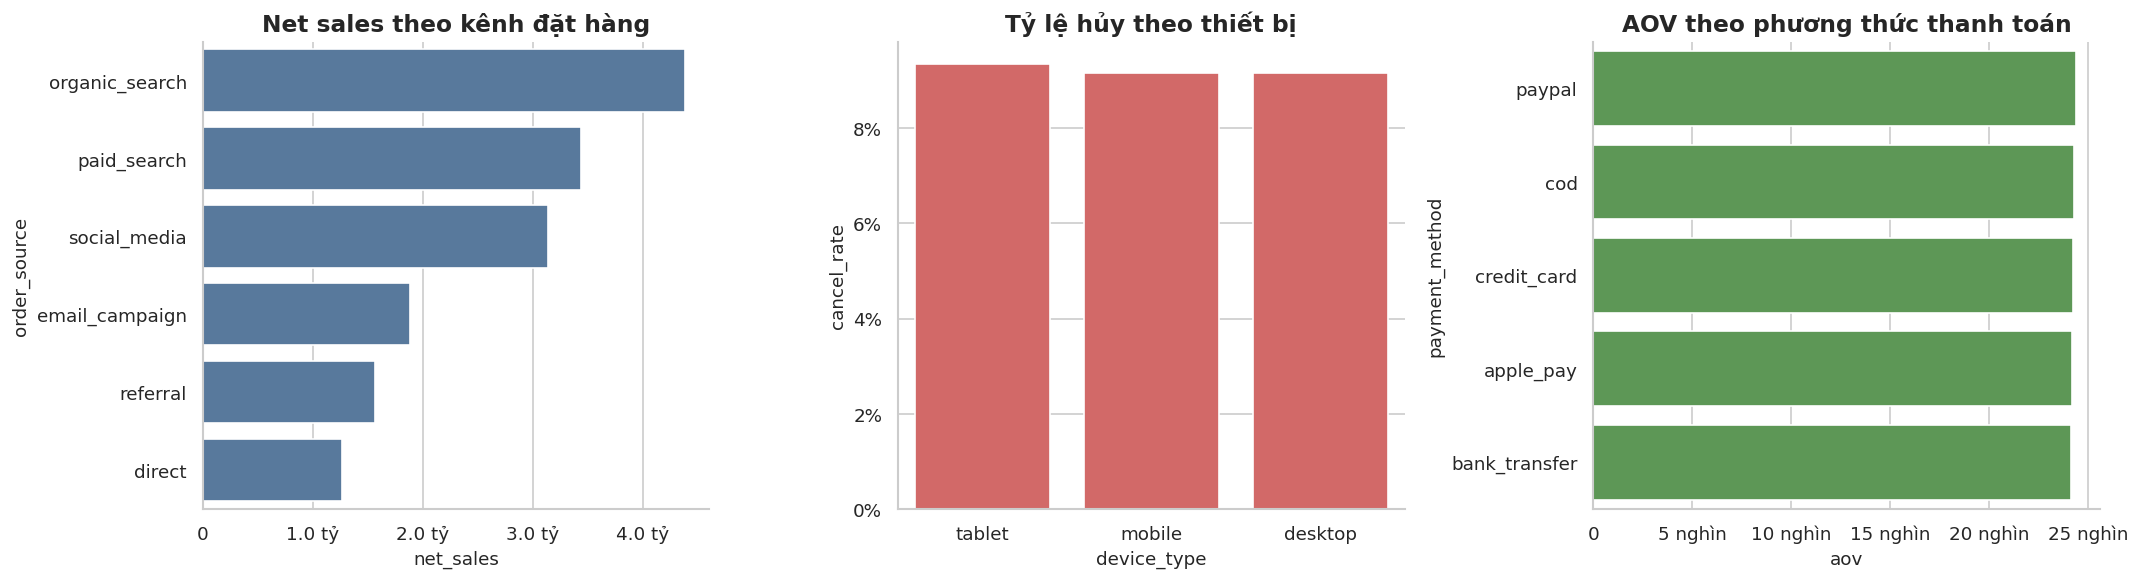

**Kết luận chung:** tăng trưởng khách hàng cần gắn với repeat rate (75.23%), chu kỳ mua lại (144 ngày), chất lượng kênh và khu vực. Ưu tiên nên dành cho phân khúc/kênh có chi tiêu cao, tỷ lệ hủy thấp và khả năng mua lại tốt.

In [5]:
source = fact.groupby("order_source", as_index=False).agg(orders=("order_id", "nunique"), net_sales=("net_sales", "sum"), aov=("net_sales", "mean"), cancel_rate=("order_status", lambda x: (x == "cancelled").mean())).sort_values("net_sales", ascending=False)
device = fact.groupby("device_type", as_index=False).agg(orders=("order_id", "nunique"), net_sales=("net_sales", "sum"), aov=("net_sales", "mean"), cancel_rate=("order_status", lambda x: (x == "cancelled").mean())).sort_values("cancel_rate", ascending=False)
payment = fact.groupby("payment_method", as_index=False).agg(orders=("order_id", "nunique"), aov=("net_sales", "mean"), cancel_rate=("order_status", lambda x: (x == "cancelled").mean()), avg_installments=("installments", "mean")).sort_values("aov", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=source, y="order_source", x="net_sales", color="#4c78a8", ax=axes[0]); axes[0].set_title("Net sales theo kênh đặt hàng"); axes[0].xaxis.set_major_formatter(plt.FuncFormatter(money_formatter))
sns.barplot(data=device, x="device_type", y="cancel_rate", color="#e45756", ax=axes[1]); axes[1].set_title("Tỷ lệ hủy theo thiết bị"); format_percent_axis(axes[1])
sns.barplot(data=payment, y="payment_method", x="aov", color="#54a24b", ax=axes[2]); axes[2].set_title("AOV theo phương thức thanh toán"); axes[2].xaxis.set_major_formatter(plt.FuncFormatter(money_formatter))
save_figure("02_customer_market_channels", fig); plt.show()
display(Markdown(f"**Kết luận chung:** tăng trưởng khách hàng cần gắn với repeat rate ({repeat_share:.2%}), chu kỳ mua lại ({median_gap:.0f} ngày), chất lượng kênh và khu vực. Ưu tiên nên dành cho phân khúc/kênh có chi tiêu cao, tỷ lệ hủy thấp và khả năng mua lại tốt."))